# EDA of the encoder input (T = 64, every window padded to 64 + mask)

This notebook looks at the windows the encoder will read, in `src/data/encoder_input/benign_gridsybil/T64/` (built by
`src/pipeline/benign_gridsybil/encoder_input_T64.ipynb`). Each window holds up to 64 real messages × 13 features and is padded to 64
rows, with a mask (1 = real message, 0 = padding). Values are already normalised (z-scores from the
train split). Labels are read from the `_info` files **for analysis only**. Nothing is written.

In [1]:
import json
import multiprocessing
import pathlib
import os
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

for _folder in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:  # notebooks live in src/<folder>/; work from the repo root
    if (_folder / "CLAUDE.md").is_file():
        os.chdir(_folder)
        break
assert pathlib.Path("CLAUDE.md").is_file() and pathlib.Path("data").is_dir(), "run from the repo root"

ROOT = pathlib.Path("src/data/encoder_input/benign_gridsybil/T64")
META = json.loads((ROOT / "metadata.json").read_text())
FEATURES: list[str] = META["features"]
SPLITS = ["train", "pretrain_val", "val", "test"]
COLOURS = {"Benign": "#16A34A", "GridSybil": "#BE185D"}
pd.set_option("display.width", 160)
print(f"{len(FEATURES)} features; window length {META['max_seq_len']}; overall padding {META['padding']['overall']:.1%}")

13 features; window length 64; overall padding 71.0%


## Load every shard

`EncoderInputLoader` reads the shards in parallel. Every window is now 64 rows, so there is one array of shape
(windows, 64, 13) plus a (windows, 64) mask; the loader still groups by the folder name (`b64`), so it would also
read the bucketed variant. `info` holds one row per window (split, label, number of real messages, sender,
receiver).

In [2]:
def _read_shard(path: str) -> tuple[str, str, np.ndarray, np.ndarray, list[dict[str, Any]]]:
    """Reads one shard and its info file (top-level so the process pool can call it)."""
    p = pathlib.Path(path)
    data = json.loads(p.read_text())
    info = json.loads(p.with_name(p.stem + "_info.json").read_text())["windows"]
    x = np.asarray([w["x"] for w in data["windows"]], dtype=np.float32)
    mask = np.asarray([w["mask"] for w in data["windows"]], dtype=np.uint8)
    return p.parts[-3], p.parts[-2], x, mask, info


class EncoderInputLoader:
    """Loads the sharded encoder input into one (x, mask) pair per bucket plus a window table."""

    def __init__(self, root: pathlib.Path, workers: int = 8) -> None:
        self.root = root
        self.workers = workers

    def load(self) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray], pd.DataFrame]:
        """Returns (x by bucket, mask by bucket, info table with a row index into its bucket)."""
        paths = sorted(str(p) for p in self.root.glob("*/b*/part-?????.json"))
        with multiprocessing.get_context("fork").Pool(self.workers) as pool:
            parts = pool.map(_read_shard, paths)
        xs: dict[int, list] = {}
        ms: dict[int, list] = {}
        rows: list[dict[str, Any]] = []
        for split, bucket_dir, x, mask, info in parts:
            bucket = int(bucket_dir[1:])
            offset = sum(len(a) for a in xs.get(bucket, []))
            xs.setdefault(bucket, []).append(x)
            ms.setdefault(bucket, []).append(mask)
            for k, r in enumerate(info):
                rows.append({**r, "split": split, "bucket": bucket, "row": offset + k})
        x_by = {b: np.concatenate(v) for b, v in xs.items()}
        m_by = {b: np.concatenate(v) for b, v in ms.items()}
        return x_by, m_by, pd.DataFrame(rows)


_t = time.perf_counter()
X, MASK, info = EncoderInputLoader(ROOT).load()
print(f"loaded {len(info):,} windows in {time.perf_counter() - _t:.1f} s; "
      f"buckets: {{{', '.join(f'{b}: {len(X[b]):,}' for b in sorted(X))}}}")

loaded 376,427 windows in 7.0 s; buckets: {64: 376,427}


## Counts and padding

How many windows each split and class has, and how much of the stored rows is padding, per split and class.
Padding share = padding rows ÷ all rows (every window stores 64 rows).

In [3]:
stored = info["bucket"].astype(int)
info["padding_rows"] = stored - info["n_messages"]
counts = info.groupby(["split", "label_name"]).agg(windows=("id", "size"), real_rows=("n_messages", "sum"),
                                                   padding_rows=("padding_rows", "sum"))
counts["padding_share"] = (counts["padding_rows"] / (counts["real_rows"] + counts["padding_rows"])).round(3)
counts = counts.reindex(SPLITS, level=0)
print(counts.to_string())
benign_share = info.groupby("split")["label_name"].apply(lambda s: s.eq("Benign").mean()).reindex(SPLITS)
print("\nbenign share per split:", benign_share.round(3).to_dict())
total_rows = int(stored.sum())
overall_pad = 1 - info["n_messages"].sum() / total_rows
print(f"Takeaway: {info['label_name'].eq('Benign').mean():.1%} of windows are benign; padding is "
      f"{overall_pad:.1%} of all {total_rows:,} stored rows.")

                         windows  real_rows  padding_rows  padding_share
split        label_name                                                 
train        Benign        84282    1663270       3730778          0.692
             GridSybil    152150    2715718       7021882          0.721
pretrain_val Benign         8517     173036        372052          0.683
             GridSybil     19889     348566        924330          0.726
val          Benign        19970     382040        896040          0.701
             GridSybil     37651     698159       1711505          0.710
test         Benign        20045     397597        885283          0.690
             GridSybil     33923     601970       1569102          0.723

benign share per split: {'train': 0.356, 'pretrain_val': 0.3, 'val': 0.347, 'test': 0.371}
Takeaway: 35.3% of windows are benign; padding is 71.0% of all 24,091,328 stored rows.


## Window length and the length shortcut

`n_messages` = real messages in a window. If one class has many more short windows, a model could use length as
a clue instead of the motion (a shortcut). The probe below fits a logistic regression on **length only**
(train → val); an AUC near 0.5 means length says little about the class.

               count    mean  25%   50%   75%   90%   max  share_1_to_3  share_full_64
label_name                                                                            
Benign      132814.0  19.696  7.0  15.0  27.0  48.0  64.0         0.139          0.056
GridSybil   243613.0  17.915  4.0  12.0  24.0  49.0  64.0         0.202          0.064


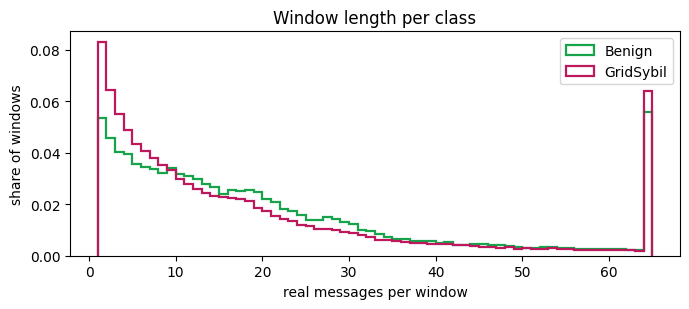

Takeaway: length-only probe val AUC = 0.531 (0.5 = chance).


In [4]:
class LengthReport:
    """Window-length distribution per class and a length-only probe."""

    def __init__(self, table: pd.DataFrame) -> None:
        self.table = table

    def summary(self) -> pd.DataFrame:
        """Length statistics per class."""
        g = self.table.groupby("label_name")["n_messages"]
        out = g.describe(percentiles=[0.25, 0.5, 0.75, 0.9])[["count", "mean", "25%", "50%", "75%", "90%", "max"]]
        out["share_1_to_3"] = g.apply(lambda n: (n <= 3).mean())
        out["share_full_64"] = g.apply(lambda n: (n == 64).mean())
        return out.round(3)

    def probe_auc(self) -> float:
        """Val AUC of a logistic regression that sees only the number of real messages."""
        tr = self.table[self.table["split"] == "train"]
        va = self.table[self.table["split"] == "val"]
        model = LogisticRegression(class_weight="balanced").fit(tr[["n_messages"]], tr["is_attack"])
        return float(roc_auc_score(va["is_attack"], model.predict_proba(va[["n_messages"]])[:, 1]))


length = LengthReport(info)
print(length.summary().to_string())
auc_len = length.probe_auc()
fig, ax = plt.subplots(figsize=(7, 3.2))
for name, colour in COLOURS.items():
    n = info.loc[info["label_name"] == name, "n_messages"]
    ax.hist(n, bins=np.arange(1, 66), density=True, histtype="step", lw=1.6, color=colour, label=name)
ax.set_xlabel("real messages per window"); ax.set_ylabel("share of windows"); ax.legend()
ax.set_title("Window length per class"); plt.tight_layout(); plt.show()
print(f"Takeaway: length-only probe val AUC = {auc_len:.3f} (0.5 = chance).")

## Padding and why the mask matters

Left: the share of windows that still have a real message at each of the 64 positions. Real rows are always
at the start, so the curve only falls; where it is low, almost every value the encoder sees is padding.
Right: what happens if the encoder **ignores the mask** and averages all 64 rows. The padding zeros pull the
average towards 0 by an amount that depends only on the window length, so the plain average quietly encodes
length. The table compares, per feature, the val AUC of the plain average with the masked average (real rows
only). A gap between the two is information that comes from padding, not from motion.

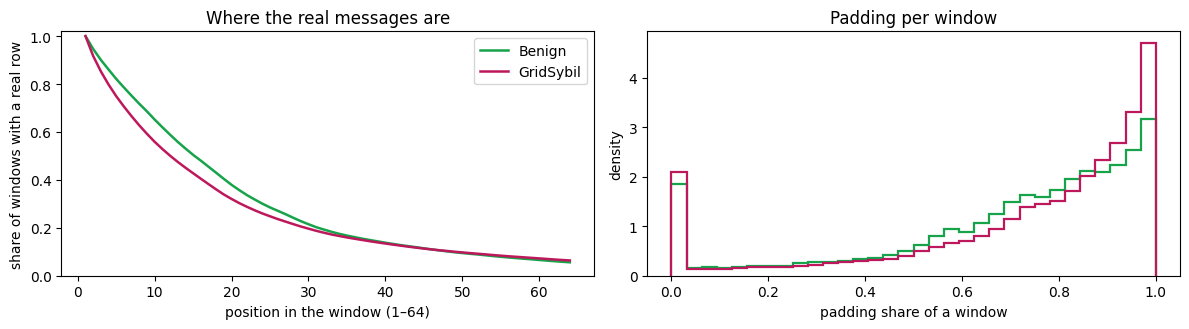

               plain_mean_auc  masked_mean_auc    gap
log_dtau                0.442            0.492  0.050
range                   0.530            0.510  0.020
rx_pos_y                0.489            0.498  0.008
claimed_pos_y           0.485            0.493  0.008
bearing                 0.508            0.502  0.006
claimed_vel_y           0.491            0.496  0.004
claimed_vel_x           0.534            0.532  0.002
rx_vel_y                0.494            0.494 -0.000
claimed_acl_y           0.516            0.516 -0.000
rx_vel_x                0.497            0.495 -0.001
claimed_acl_x           0.502            0.506 -0.004
rx_pos_x                0.468            0.463 -0.005
claimed_pos_x           0.471            0.466 -0.005
Takeaway: half of the windows are already padding from position 16 (benign) / 13 (GridSybil); at position 64 only 5.6% / 6.4% are real. Ignoring the mask moves the best single-feature AUC from 0.537 to 0.558 (distance from 0.5 shown as AUC ≥ 0.

In [5]:
class PaddingReport:
    """How padding is spread over positions and what an unmasked average would leak."""

    def __init__(self, x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame) -> None:
        self.x_by, self.m_by, self.table = x_by, m_by, table

    def real_share_by_position(self, label: str) -> np.ndarray:
        """Share of the class's windows with a real row at each position (64 values)."""
        sel = self.table[self.table["label_name"] == label]
        return np.concatenate([self.m_by[b][sel.loc[sel["bucket"] == b, "row"].to_numpy()]
                               for b in self.m_by]).mean(axis=0)

    def masked_vs_plain_auc(self, split: str = "val") -> pd.DataFrame:
        """Val AUC per feature of the plain (all rows) and the masked (real rows) window average."""
        plain, masked, labels = [], [], []
        for b, x in self.x_by.items():
            sel = self.table[(self.table["bucket"] == b) & (self.table["split"] == split)]
            idx = sel["row"].to_numpy()
            m = self.m_by[b][idx].astype(np.float32)[..., None]
            plain.append(x[idx].mean(1))
            masked.append((x[idx] * m).sum(1) / m.sum(1))
            labels.append(sel["is_attack"].to_numpy())
        plain, masked, y = np.concatenate(plain), np.concatenate(masked), np.concatenate(labels)
        out = pd.DataFrame({"plain_mean_auc": [roc_auc_score(y, plain[:, j]) for j in range(len(FEATURES))],
                            "masked_mean_auc": [roc_auc_score(y, masked[:, j]) for j in range(len(FEATURES))]},
                           index=FEATURES)
        out["gap"] = (out["plain_mean_auc"] - 0.5).abs() - (out["masked_mean_auc"] - 0.5).abs()
        return out.sort_values("gap", ascending=False).round(3)


padding = PaddingReport(X, MASK, info)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.4))
for name, colour in COLOURS.items():
    ax1.plot(np.arange(1, 65), padding.real_share_by_position(name), color=colour, lw=1.8, label=name)
    share = info.loc[info["label_name"] == name, "padding_rows"] / info.loc[info["label_name"] == name, "bucket"]
    ax2.hist(share, bins=np.linspace(0, 1, 33), density=True, histtype="step", lw=1.6, color=colour, label=name)
ax1.set_xlabel("position in the window (1–64)"); ax1.set_ylabel("share of windows with a real row")
ax1.set_title("Where the real messages are"); ax1.legend(); ax1.set_ylim(0, 1.02)
ax2.set_xlabel("padding share of a window"); ax2.set_ylabel("density"); ax2.set_title("Padding per window")
plt.tight_layout(); plt.show()
leak = padding.masked_vs_plain_auc("val")
print(leak.to_string())
real_at = {n: padding.real_share_by_position(n) for n in COLOURS}
half = {n: int(np.argmax(v < 0.5)) + 1 for n, v in real_at.items()}
print(f"Takeaway: half of the windows are already padding from position {half['Benign']} (benign) / "
      f"{half['GridSybil']} (GridSybil); at position 64 only {real_at['Benign'][-1]:.1%} / "
      f"{real_at['GridSybil'][-1]:.1%} are real. Ignoring the mask moves the best single-feature AUC from "
      f"{(leak['masked_mean_auc'] - 0.5).abs().max() + 0.5:.3f} to {(leak['plain_mean_auc'] - 0.5).abs().max() + 0.5:.3f} "
      f"(distance from 0.5 shown as AUC ≥ 0.5) — the difference is padding, not motion.")

## Feature values per class (real rows only)

Quantiles of every normalised feature for benign and GridSybil real rows (padding excluded), and how often a
value is extreme (|z| > 3 and > 10). Extreme values are mostly far-away claimed positions.

In [6]:
class FeatureReport:
    """Per-class statistics of the real (unpadded) rows."""

    def __init__(self, x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame) -> None:
        self.x_by, self.m_by, self.table = x_by, m_by, table

    def real_rows(self, label: str | None = None, split: str | None = None) -> np.ndarray:
        """All real rows (n, 13) of the windows matching the label / split filters."""
        chunks = []
        for b, x in self.x_by.items():
            sel = self.table[self.table["bucket"] == b]
            if label is not None:
                sel = sel[sel["label_name"] == label]
            if split is not None:
                sel = sel[sel["split"] == split]
            idx = sel["row"].to_numpy()
            chunks.append(x[idx][self.m_by[b][idx].astype(bool)])
        return np.concatenate(chunks)

    def quantiles(self) -> pd.DataFrame:
        """Median and 1% / 99% quantiles plus extreme shares, per feature and class."""
        rows = []
        for label in COLOURS:
            r = self.real_rows(label)
            for j, f in enumerate(FEATURES):
                v = r[:, j]
                rows.append({"feature": f, "class": label, "p01": np.quantile(v, 0.01),
                             "median": np.median(v), "p99": np.quantile(v, 0.99),
                             "share_|z|>3": np.mean(np.abs(v) > 3), "share_|z|>10": np.mean(np.abs(v) > 10),
                             "max_|z|": np.abs(v).max()})
        return pd.DataFrame(rows).set_index(["feature", "class"]).round(3)


features = FeatureReport(X, MASK, info)
quant = features.quantiles()
print(quant.to_string())
ext = quant["share_|z|>10"].unstack("class")
extreme = [f"{f} ({ext.loc[f, 'GridSybil']:.2%} GridSybil vs {ext.loc[f, 'Benign']:.2%} benign)"
           for f in ext.index if ext.loc[f].max() > 0.0005]
print("Takeaway: values beyond |z| > 10 appear in " + (", ".join(extreme) or "no feature") + ".")

                           p01  median    p99  share_|z|>3  share_|z|>10    max_|z|
feature       class                                                                
claimed_pos_x Benign    -0.785  -0.513  1.927        0.000         0.000   1.964000
claimed_pos_y Benign    -1.543   0.111  1.324        0.000         0.000   1.847000
rx_pos_x      Benign    -0.912  -0.592  2.268        0.000         0.000   2.312000
rx_pos_y      Benign    -1.970   0.142  1.693        0.000         0.000   2.354000
claimed_vel_x Benign    -2.867   0.006  2.935        0.011         0.000   3.582000
claimed_vel_y Benign    -2.600  -0.015  2.568        0.000         0.000   3.106000
rx_vel_x      Benign    -2.043  -0.000  2.078        0.000         0.000   2.547000
rx_vel_y      Benign    -1.877  -0.029  1.831        0.000         0.000   2.328000
claimed_acl_x Benign    -2.843  -0.000  3.645        0.022         0.000   4.686000
claimed_acl_y Benign    -3.540   0.007  3.488        0.032         0.000   3

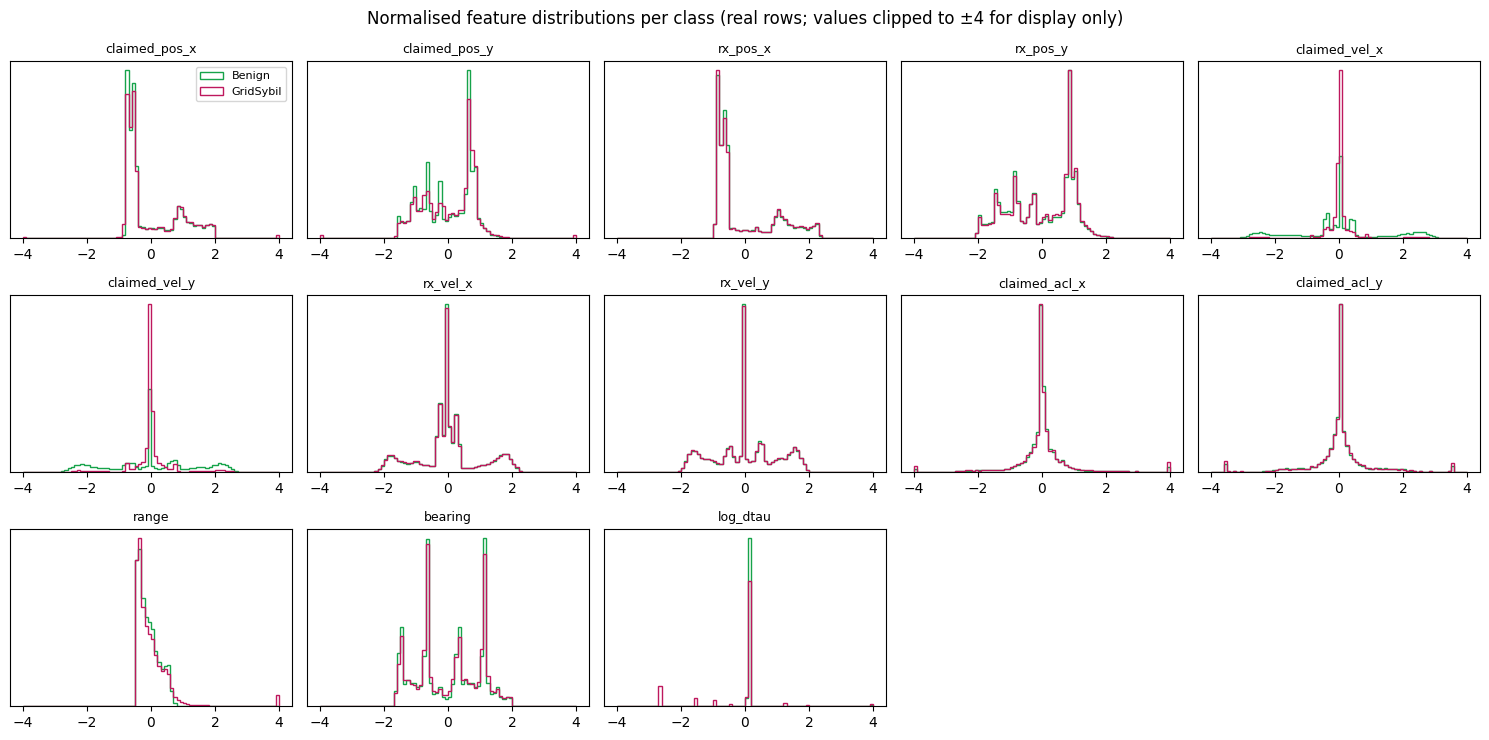

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(15, 7.5))
benign_rows = features.real_rows("Benign")
grid_rows = features.real_rows("GridSybil")
for j, ax in enumerate(axes.flat):
    if j >= len(FEATURES):
        ax.axis("off"); continue
    bins = np.linspace(-4, 4, 81)
    for rows, name in ((benign_rows, "Benign"), (grid_rows, "GridSybil")):
        ax.hist(np.clip(rows[:, j], -4, 4), bins=bins, density=True, histtype="step", color=COLOURS[name], label=name)
    ax.set_title(FEATURES[j], fontsize=9); ax.set_yticks([])
axes.flat[0].legend(fontsize=8)
fig.suptitle("Normalised feature distributions per class (real rows; values clipped to ±4 for display only)")
plt.tight_layout(); plt.show()

## Does the train normalisation hold in the other splits?

On train real rows every feature should have mean ≈ 0 and std ≈ 1 (that is how it was fitted). Val and test
should be close; a large shift would mean the splits differ in a way the model has to cope with.

In [8]:
norm_rows = []
for split in SPLITS:
    r = features.real_rows(split=split)
    for j, f in enumerate(FEATURES):
        norm_rows.append({"split": split, "feature": f, "mean": r[:, j].mean(), "std": r[:, j].std()})
norm = pd.DataFrame(norm_rows).pivot(index="feature", columns="split", values=["mean", "std"]).round(3)
print(norm.to_string())
shift = norm["mean"].sub(norm["mean"]["train"], axis=0).abs().drop(columns="train").max().max()
print(f"Takeaway: the largest mean shift from train in another split is {shift:.3f} standard deviations.")

                      mean                              std                     
split         pretrain_val   test train    val pretrain_val   test  train    val
feature                                                                         
bearing              0.022  0.017   0.0  0.017        0.994  0.995  1.000  0.988
claimed_acl_x        0.000  0.003   0.0  0.019        0.958  1.058  1.000  0.983
claimed_acl_y       -0.006 -0.017   0.0  0.004        0.988  1.014  1.000  1.043
claimed_pos_x       -0.043  0.039  -0.0 -0.028        0.854  1.235  1.000  1.016
claimed_pos_y       -0.025  0.054  -0.0 -0.045        0.813  1.384  1.000  1.308
claimed_vel_x        0.032  0.039   0.0  0.009        0.915  1.015  1.000  0.995
claimed_vel_y        0.008 -0.003  -0.0  0.039        0.982  1.014  1.000  0.979
log_dtau            -0.013 -0.088   0.0 -0.049        1.006  1.079  0.974  1.027
range               -0.038  0.103  -0.0  0.101        0.457  1.678  1.000  1.434
rx_pos_x            -0.051  

## How the features move together

Correlation between features over a sample of real rows. Strong pairs carry partly the same information (for
example the receiver's own position and the claimed position of nearby honest senders).

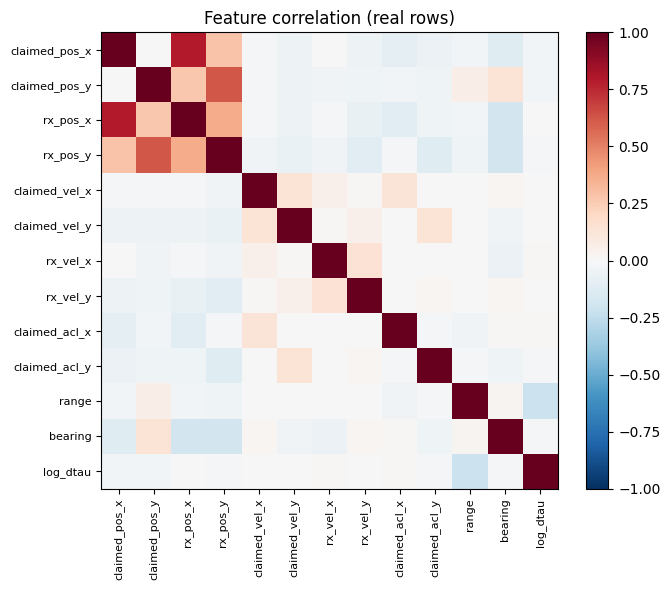

Takeaway: strongest pairs: claimed_pos_x ~ rx_pos_x (+0.79); claimed_pos_y ~ rx_pos_y (+0.62); rx_pos_x ~ rx_pos_y (+0.37); claimed_pos_x ~ rx_pos_y (+0.28); claimed_pos_y ~ rx_pos_x (+0.27)


In [9]:
rng = np.random.default_rng(0)
all_rows = np.concatenate([benign_rows, grid_rows])
sample = all_rows[rng.choice(len(all_rows), size=min(200_000, len(all_rows)), replace=False)]
corr = np.corrcoef(sample.T)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046); ax.set_title("Feature correlation (real rows)")
plt.tight_layout(); plt.show()
pairs = [(FEATURES[i], FEATURES[j], corr[i, j]) for i in range(len(FEATURES)) for j in range(i + 1, len(FEATURES))]
top = sorted(pairs, key=lambda t: -abs(t[2]))[:5]
print("Takeaway: strongest pairs:", "; ".join(f"{a} ~ {b} ({c:+.2f})" for a, b, c in top))

## Which single features separate benign from GridSybil?

For each feature, the window average over real rows is used as a score, and its AUC between benign and GridSybil
is measured on the val split (no model is trained). AUC 0.5 = no separation; the further from 0.5 (in either
direction), the more that feature alone tells the classes apart. This is a rough look, not a result.

In [10]:
class SingleFeatureSeparation:
    """AUC of each feature's per-window mean (real rows only) for benign vs GridSybil."""

    def __init__(self, x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame) -> None:
        self.x_by, self.m_by, self.table = x_by, m_by, table

    def window_means(self, split: str) -> tuple[np.ndarray, np.ndarray]:
        """Per-window means (n, 13) and attack labels for one split."""
        means, labels = [], []
        for b, x in self.x_by.items():
            sel = self.table[(self.table["bucket"] == b) & (self.table["split"] == split)]
            idx = sel["row"].to_numpy()
            m = self.m_by[b][idx].astype(np.float32)[..., None]
            means.append((x[idx] * m).sum(1) / m.sum(1))
            labels.append(sel["is_attack"].to_numpy())
        return np.concatenate(means), np.concatenate(labels)

    def table_auc(self, split: str = "val") -> pd.Series:
        """AUC per feature, sorted by distance from 0.5."""
        means, y = self.window_means(split)
        auc = pd.Series({f: roc_auc_score(y, means[:, j]) for j, f in enumerate(FEATURES)})
        return auc.reindex((auc - 0.5).abs().sort_values(ascending=False).index).round(3)


separation = SingleFeatureSeparation(X, MASK, info).table_auc("val")
print(separation.to_string())
best = separation.index[0]
print(f"Takeaway: the strongest single feature is {best} (val AUC {separation.iloc[0]:.3f}); "
      f"{int(((separation - 0.5).abs() > 0.1).sum())} of 13 features reach |AUC − 0.5| > 0.1 on their own.")

rx_pos_x         0.463
claimed_pos_x    0.466
claimed_vel_x    0.532
claimed_acl_y    0.516
range            0.510
log_dtau         0.492
claimed_pos_y    0.493
rx_vel_y         0.494
claimed_acl_x    0.506
rx_vel_x         0.495
claimed_vel_y    0.496
rx_pos_y         0.498
bearing          0.502
Takeaway: the strongest single feature is rx_pos_x (val AUC 0.463); 0 of 13 features reach |AUC − 0.5| > 0.1 on their own.


## Repeated broadcasts across windows

One broadcast is heard by several cars, so the **claimed** columns (what the sender says) of a window can be
identical in another receiver's window. This counts windows whose first real message carries exactly the same
claimed values as some other window — a sign of correlated samples (they always stay in the same split, because
the split is by sender).

In [11]:
claimed_cols = [FEATURES.index(c) for c in ("claimed_pos_x", "claimed_pos_y", "claimed_vel_x", "claimed_vel_y")]
keys = []
for b, x in X.items():
    sel = info[info["bucket"] == b]
    first = x[sel["row"].to_numpy(), 0][:, claimed_cols]
    keys.append(pd.DataFrame({"key": [tuple(r) for r in np.round(first, 4)], "label": sel["label_name"].to_numpy(),
                              "split": sel["split"].to_numpy()}))
keys = pd.concat(keys, ignore_index=True)
dup = keys.duplicated("key", keep=False)
print(keys.assign(repeated=dup).groupby("label")["repeated"].mean().round(3).to_string())
same_split = keys[dup].groupby("key")["split"].nunique().eq(1).mean()
norm_stats = META["normalisation"]
vel_mean = np.array([norm_stats["mean"][FEATURES.index(c)] for c in ("claimed_vel_x", "claimed_vel_y")])
vel_std = np.array([norm_stats["std"][FEATURES.index(c)] for c in ("claimed_vel_x", "claimed_vel_y")])
cross = keys[dup].groupby("key")["split"].nunique().loc[lambda s: s > 1].index
cross_speed = np.array([np.hypot(*(np.array(k[2:]) * vel_std + vel_mean)) for k in cross])
print(f"Takeaway: {dup.mean():.1%} of windows share their first claimed message with another window; "
      f"{same_split:.1%} of those groups stay inside one split. The {len(cross)} groups that cross splits are "
      f"{np.mean(cross_speed < 0.1):.1%} standing cars (claimed speed < 0.1 m/s at the same spot), i.e. different "
      f"vehicles that happen to report the same values, not copies of one broadcast.")

label
Benign       0.525
GridSybil    0.584
Takeaway: 56.3% of windows share their first claimed message with another window; 98.5% of those groups stay inside one split. The 894 groups that cross splits are 100.0% standing cars (claimed speed < 0.1 m/s at the same spot), i.e. different vehicles that happen to report the same values, not copies of one broadcast.


## Summary

The numbers above, in one place. They describe the input; they are not model results.

In [12]:
summary = {
    "windows": len(info),
    "benign share": f"{info['label_name'].eq('Benign').mean():.1%}",
    "window shape": "64 × 13 (+ 64-value mask)",
    "padding overall": f"{overall_pad:.1%}",
    "best single-feature AUC, masked vs plain mean": (
        f"{(leak['masked_mean_auc'] - 0.5).abs().max() + 0.5:.3f} vs {(leak['plain_mean_auc'] - 0.5).abs().max() + 0.5:.3f}"),
    "1–3-message windows (benign / GridSybil)": " / ".join(
        f"{(info.loc[info['label_name'] == c, 'n_messages'] <= 3).mean():.1%}" for c in COLOURS),
    "length-only probe AUC (val)": round(auc_len, 3),
    "largest mean shift vs train (std units)": round(float(shift), 3),
    "strongest single feature (val AUC)": f"{best} ({separation.iloc[0]:.3f})",
    "windows sharing a first claimed message": f"{dup.mean():.1%}",
}
pd.Series(summary, name="value").to_frame()

,value
windows,376427
benign share,35.3%
window shape,64 × 13 (+ 64-value mask)
padding overall,71.0%
"best single-feature AUC, masked vs plain mean",0.537 vs 0.558
1–3-message windows (benign / GridSybil),13.9% / 20.2%
length-only probe AUC (val),0.531
largest mean shift vs train (std units),0.103
strongest single feature (val AUC),rx_pos_x (0.463)
windows sharing a first claimed message,56.3%
